# **Brain Tumor Classification**



## **Importing Libraries**

In [1]:
import os
import zipfile
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### **Reproducibility**

A fixed random seed is used where possible so that dataset splitting, initialization, and experiments are more reproducible.

In [2]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


## **Dataset Acquisition**

In [3]:
# Install Kaggle CLI
!pip install -q kaggle

In [4]:
os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

os.remove("kaggle.json")

print("Kaggle authentication configured.")

Kaggle authentication configured.


In [5]:
# Testing API
!kaggle datasets files ishans24/brain-tumor-dataset

Next Page Token = CfDJ8GNxPX3qpaJEpxfoBSRBZPdft-d7EN0xJsf2I0W9gSoVBh4e34AZvltpJvbSxn1JxoCYf8sL-4GXoRwKvgxf0wpnKW9_BSi1q04UL4EI8Hsxr7cgIqjHmJ9CknoLRBx1vROBx9gGCO_x8geZURc
name                     size  creationDate                
---------------------  ------  --------------------------  
glioma/glioma1.png     162328  2025-09-09 20:56:41.439000  
glioma/glioma10.png    234814  2025-09-09 20:56:39.069000  
glioma/glioma100.png   215802  2025-09-09 20:56:39.451000  
glioma/glioma1000.png  254001  2025-09-09 20:56:42.967000  
glioma/glioma1001.png  277153  2025-09-09 20:56:39.040000  
glioma/glioma1002.png  225812  2025-09-09 20:56:39.998000  
glioma/glioma1003.png  223582  2025-09-09 20:56:41.911000  
glioma/glioma1004.png  187030  2025-09-09 20:56:43.670000  
glioma/glioma1005.png  221771  2025-09-09 20:56:40.618000  
glioma/glioma1006.png  274983  2025-09-09 20:56:40.659000  
glioma/glioma1007.png  198249  2025-09-09 20:56:40.408000  
glioma/glioma1008.png  215424  2025-09-09 20:56:40

In [6]:
# Downloading Dataset
!kaggle datasets download \
    -d ishans24/brain-tumor-dataset \
    -p /content/raw_classification

Dataset URL: https://www.kaggle.com/datasets/ishans24/brain-tumor-dataset
License(s): MIT
100% 862M/862M [00:41<00:00, 21.7MB/s]



## **Extracting the Dataset**

In [7]:
RAW_DIR = "/content/raw_classification"
ZIP_PATH = os.path.join(RAW_DIR, "brain-tumor-dataset.zip")

EXTRACT_DIR = "/content/classification_dataset"

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [8]:
for root, dirs, files in os.walk(EXTRACT_DIR):
    print(root, "->", len(files), "files")

/content/classification_dataset -> 0 files
/content/classification_dataset/glioma -> 3754 files
/content/classification_dataset/pituitary -> 2706 files
/content/classification_dataset/meningioma -> 2343 files
/content/classification_dataset/no_tumor -> 1757 files


## **Dataset Inspection**

In [9]:
CLASS_NAMES = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

class_paths = {}

for class_name in CLASS_NAMES:
    for root, dirs, files in os.walk(EXTRACT_DIR):
        if os.path.basename(root).lower() == class_name:
            class_paths[class_name] = root
            break

for class_name, path in class_paths.items():
    print(f"{class_name:12} -> {path}")

glioma       -> /content/classification_dataset/glioma
meningioma   -> /content/classification_dataset/meningioma
no_tumor     -> /content/classification_dataset/no_tumor
pituitary    -> /content/classification_dataset/pituitary


### **Class Distribution**

In [10]:
IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

class_counts = {}

for class_name, class_path in class_paths.items():

    count = sum(
        1
        for file in os.listdir(class_path)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    )

    class_counts[class_name] = count

for class_name, count in class_counts.items():
    print(f"{class_name:12}: {count}")

print("\nTotal images:", sum(class_counts.values()))

glioma      : 3754
meningioma  : 2343
no_tumor    : 1757
pituitary   : 2706

Total images: 10560


### **Raw Image Inspection**

In [11]:
sample_paths = {}

for class_name, class_path in class_paths.items():

    image_files = [
        file
        for file in os.listdir(class_path)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    if image_files:
        sample_paths[class_name] = os.path.join(
            class_path,
            image_files[0]
        )

for class_name, path in sample_paths.items():

    image = cv2.imread(path)

    print("=" * 60)
    print("Class:", class_name)
    print("File:", os.path.basename(path))
    print("Shape:", image.shape)
    print("Data type:", image.dtype)
    print("Minimum pixel:", image.min())
    print("Maximum pixel:", image.max())

Class: glioma
File: glioma1963.jpg
Shape: (512, 512, 3)
Data type: uint8
Minimum pixel: 0
Maximum pixel: 255
Class: meningioma
File: meningioma738.jpg
Shape: (512, 512, 3)
Data type: uint8
Minimum pixel: 0
Maximum pixel: 255
Class: no_tumor
File: no_tumor583.jpg
Shape: (217, 232, 3)
Data type: uint8
Minimum pixel: 0
Maximum pixel: 255
Class: pituitary
File: pituitary860.png
Shape: (512, 512, 3)
Data type: uint8
Minimum pixel: 1
Maximum pixel: 253


### **Raw Sample Visualization**

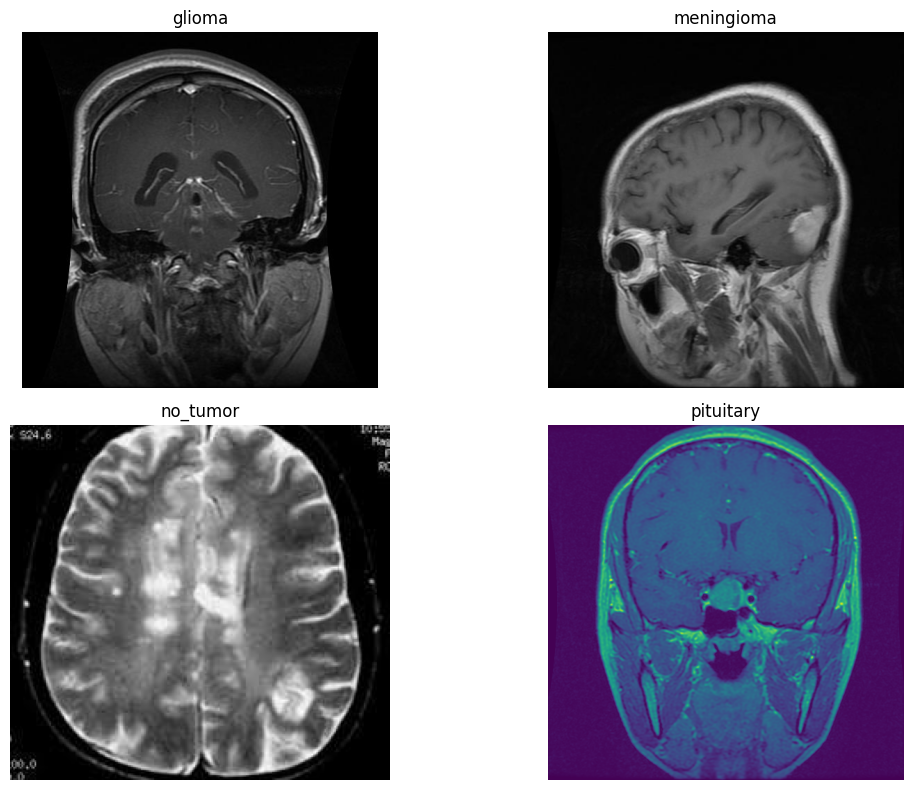

In [12]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(CLASS_NAMES):

    if class_name not in sample_paths:
        continue

    image = cv2.imread(sample_paths[class_name])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## **Image Preprocessing**

In [13]:
PROCESSED_DIR = "/content/processed_classification"

os.makedirs(PROCESSED_DIR, exist_ok=True)

for class_name in CLASS_NAMES:
    os.makedirs(
        os.path.join(PROCESSED_DIR, class_name),
        exist_ok=True
    )

print("Processed dataset directories created.")

Processed dataset directories created.


### **Preprocessing Function**

In [14]:
def preprocess_image(input_path, output_path):
    # Read image
    image = cv2.imread(input_path)

    if image is None:
        raise ValueError(f"Unable to read image: {input_path}")

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Resize to 224 × 224
    resized = cv2.resize(
        gray,
        (224, 224),
        interpolation=cv2.INTER_AREA
    )

    # Save as PNG
    success = cv2.imwrite(output_path, resized)

    if not success:
        raise ValueError(f"Unable to save image: {output_path}")

### **Preprocessing Verification**

In [15]:
test_paths = {}

for class_name in CLASS_NAMES:
    input_path = sample_paths[class_name]

    output_path = os.path.join(
        PROCESSED_DIR,
        class_name,
        "preprocessing_test.png"
    )

    preprocess_image(input_path, output_path)

    test_paths[class_name] = output_path

print("Test preprocessing completed.")

Test preprocessing completed.


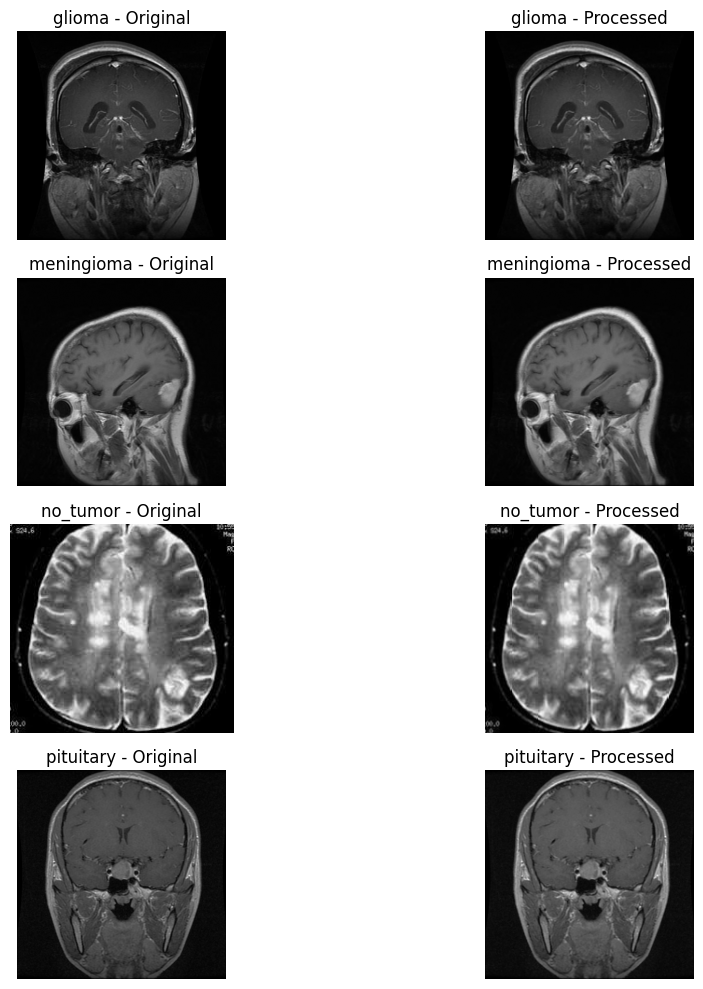

In [16]:
plt.figure(figsize=(12, 10))

for i, class_name in enumerate(CLASS_NAMES):

    original = cv2.imread(
        sample_paths[class_name],
        cv2.IMREAD_GRAYSCALE
    )

    processed = cv2.imread(
        test_paths[class_name],
        cv2.IMREAD_GRAYSCALE
    )

    # Original
    plt.subplot(4, 2, 2 * i + 1)
    plt.imshow(original, cmap="gray")
    plt.title(f"{class_name} - Original")
    plt.axis("off")

    # Processed
    plt.subplot(4, 2, 2 * i + 2)
    plt.imshow(processed, cmap="gray")
    plt.title(f"{class_name} - Processed")
    plt.axis("off")

plt.tight_layout()
plt.show()

### **Processed Image Verification**

In [17]:
for class_name, path in test_paths.items():

    image = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    print("=" * 50)
    print("Class:", class_name)
    print("Shape:", image.shape)
    print("Data type:", image.dtype)
    print("Min pixel:", image.min())
    print("Max pixel:", image.max())

Class: glioma
Shape: (224, 224)
Data type: uint8
Min pixel: 0
Max pixel: 238
Class: meningioma
Shape: (224, 224)
Data type: uint8
Min pixel: 0
Max pixel: 243
Class: no_tumor
Shape: (224, 224)
Data type: uint8
Min pixel: 0
Max pixel: 250
Class: pituitary
Shape: (224, 224)
Data type: uint8
Min pixel: 30
Max pixel: 193


In [18]:
# To Delete the test images from the 'processed_classification' directory
for path in test_paths.values():
    if os.path.exists(path):
        os.remove(path)

print("Test images removed.")

Test images removed.


## **Processing the Complete Dataset**

In [19]:
from tqdm.auto import tqdm

total_processed = 0
total_failed = 0

for class_name in CLASS_NAMES:

    input_dir = class_paths[class_name]
    output_dir = os.path.join(
        PROCESSED_DIR,
        class_name
    )

    image_files = [
        file
        for file in os.listdir(input_dir)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    ]

    print(f"\nProcessing {class_name}: {len(image_files)} images")

    for filename in tqdm(image_files):

        input_path = os.path.join(
            input_dir,
            filename
        )

        # Keep the original filename but change extension to PNG
        output_filename = os.path.splitext(filename)[0] + ".png"

        output_path = os.path.join(
            output_dir,
            output_filename
        )

        try:
            preprocess_image(
                input_path,
                output_path
            )

            total_processed += 1

        except Exception as e:
            total_failed += 1
            print(f"\nFailed: {input_path}")
            print("Reason:", e)

print("\n" + "=" * 50)
print("Preprocessing complete")
print("Successfully processed:", total_processed)
print("Failed:", total_failed)


Processing glioma: 3754 images


  0%|          | 0/3754 [00:00<?, ?it/s]


Processing meningioma: 2343 images


  0%|          | 0/2343 [00:00<?, ?it/s]


Processing no_tumor: 1757 images


  0%|          | 0/1757 [00:00<?, ?it/s]


Processing pituitary: 2706 images


  0%|          | 0/2706 [00:00<?, ?it/s]


Preprocessing complete
Successfully processed: 10560
Failed: 0


### **Final Processed Dataset Verification**

In [20]:
processed_counts = {}

for class_name in CLASS_NAMES:

    class_dir = os.path.join(
        PROCESSED_DIR,
        class_name
    )

    count = sum(
        1
        for file in os.listdir(class_dir)
        if file.lower().endswith(".png")
    )

    processed_counts[class_name] = count

for class_name, count in processed_counts.items():
    print(f"{class_name:12}: {count}")

print("\nTotal processed:", sum(processed_counts.values()))

glioma      : 3754
meningioma  : 2343
no_tumor    : 1757
pituitary   : 2706

Total processed: 10560


## **Creating the Dataset Index**

In [21]:
data = []

for class_name in CLASS_NAMES:

    class_dir = os.path.join(
        PROCESSED_DIR,
        class_name
    )

    for filename in os.listdir(class_dir):

        if filename.lower().endswith(".png"):

            data.append({
                "filepath": os.path.join(class_dir, filename),
                "label": class_name
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

Total images: 10560

Class distribution:
label
glioma        3754
pituitary     2706
meningioma    2343
no_tumor      1757
Name: count, dtype: int64


### **Dataset Index Inspection**

In [22]:
display(df.head())

print("\nDataFrame shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

,filepath,label
0,/content/processed_classification/glioma/gliom...,glioma
1,/content/processed_classification/glioma/gliom...,glioma
2,/content/processed_classification/glioma/gliom...,glioma
3,/content/processed_classification/glioma/gliom...,glioma
4,/content/processed_classification/glioma/gliom...,glioma



DataFrame shape: (10560, 2)

Missing values:
filepath    0
label       0
dtype: int64


## **Stratified Dataset Splitting**

In [23]:
# First split: 70% training, 30% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

# Second split: divide the 30% temporary set equally
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTotal:", len(train_df) + len(val_df) + len(test_df))

Training: 7392
Validation: 1584
Test: 1584

Total: 10560


### **Verifying Class Distribution After Splitting**

In [24]:
distribution = pd.DataFrame({
    "Full Dataset": df["label"].value_counts(normalize=True),
    "Training": train_df["label"].value_counts(normalize=True),
    "Validation": val_df["label"].value_counts(normalize=True),
    "Test": test_df["label"].value_counts(normalize=True)
})

distribution = distribution * 100

distribution.round(2)

,Full Dataset,Training,Validation,Test
label,,,,
glioma,35.55,35.55,35.54,35.54
pituitary,25.62,25.62,25.63,25.63
meningioma,22.19,22.19,22.16,22.22
no_tumor,16.64,16.64,16.67,16.60


### **Data Leakage Check**

In [25]:
train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])

print("Train ∩ Validation:", len(train_paths & val_paths))
print("Train ∩ Test:", len(train_paths & test_paths))
print("Validation ∩ Test:", len(val_paths & test_paths))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## **TensorFlow Input Pipeline**

In [26]:
AUTOTUNE = tf.data.AUTOTUNE

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

CLASS_TO_INDEX = {
    "glioma": 0,
    "meningioma": 1,
    "no_tumor": 2,
    "pituitary": 3
}

print("Class mapping:")
for class_name, index in CLASS_TO_INDEX.items():
    print(f"{class_name}: {index}")

Class mapping:
glioma: 0
meningioma: 1
no_tumor: 2
pituitary: 3


### **Image Loading and Normalization**

In [27]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_png(
        image,
        channels=1
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

## **Training Data Augmentation**

In [28]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        factor=0.05
    ),

    tf.keras.layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
], name="data_augmentation")

### **Training-Only Augmentation**

In [29]:
def augment_image(image, label):
    image = data_augmentation(
        image,
        training=True
    )

    return image, label

In [30]:
def create_dataset(dataframe, training=False):

    paths = dataframe["filepath"].values

    labels = dataframe["label"].map(
        CLASS_TO_INDEX
    ).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

        dataset = dataset.map(
            augment_image,
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

### **Creating the Final Data Pipelines**

In [31]:
train_ds = create_dataset(
    train_df,
    training=True
)

val_ds = create_dataset(
    val_df,
    training=False
)

test_ds = create_dataset(
    test_df,
    training=False
)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


## **Verify the Input Pipeline**

In [32]:
images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Image data type:", images.dtype)
print("Minimum pixel value:", tf.reduce_min(images).numpy())
print("Maximum pixel value:", tf.reduce_max(images).numpy())
print("Labels shape:", labels.shape)
print("Labels:", labels.numpy())

Image batch shape: (32, 224, 224, 1)
Image data type: <dtype: 'float32'>
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Labels shape: (32,)
Labels: [1 1 3 2 0 0 3 1 1 1 0 3 0 0 0 3 3 0 0 2 3 1 3 3 3 3 0 2 2 3 0 0]


### **Visualizing Augmented Training Images**

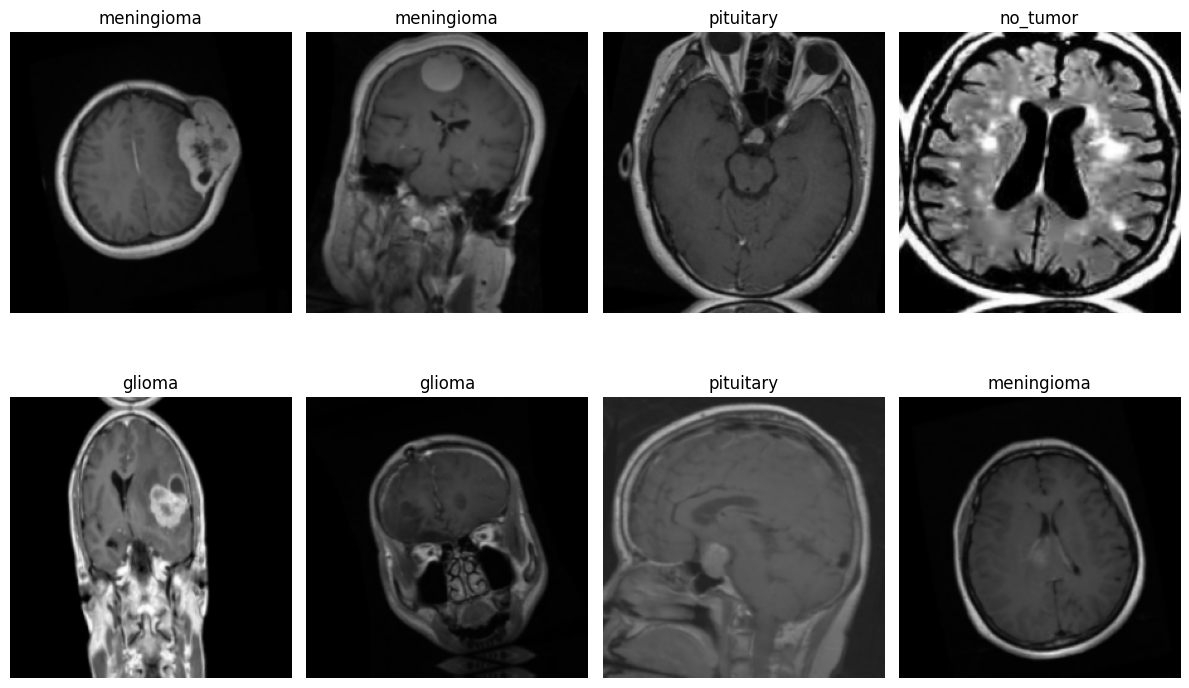

In [33]:
plt.figure(figsize=(12, 8))

for i in range(8):

    image = images[i].numpy().squeeze()
    label = labels[i].numpy()

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        list(CLASS_TO_INDEX.keys())[label]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

### **Validation and Test Pipeline Check**

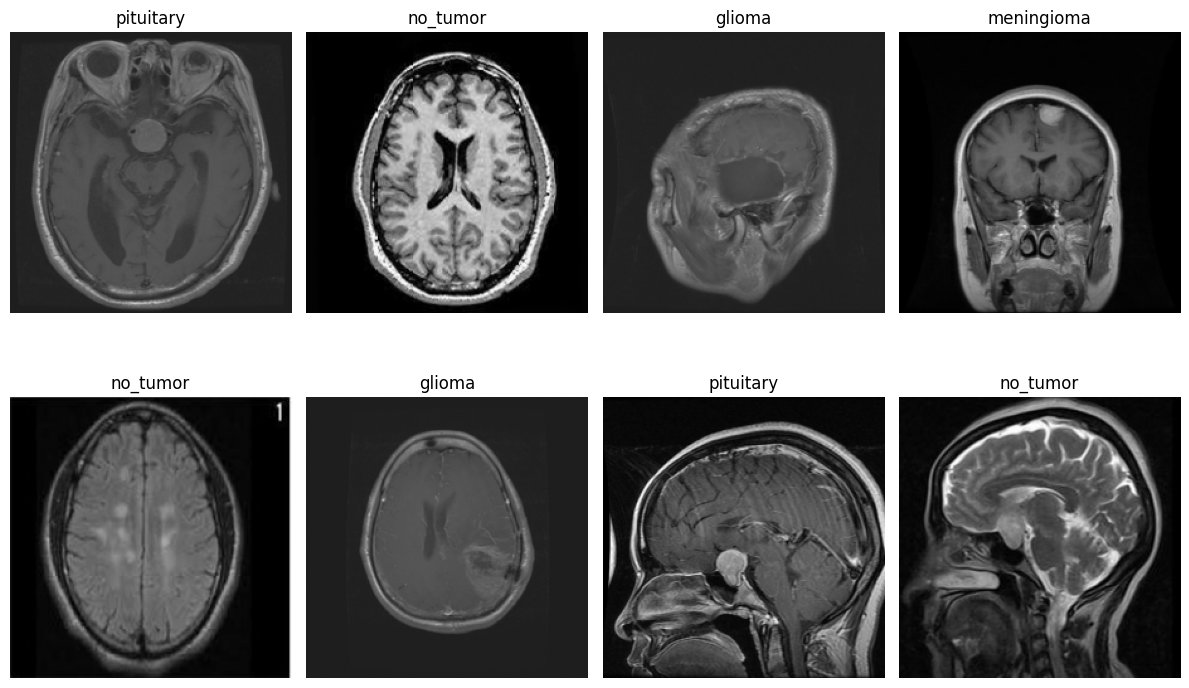

In [34]:
val_images, val_labels = next(iter(val_ds))

plt.figure(figsize=(12, 8))

for i in range(8):

    image = val_images[i].numpy().squeeze()
    label = val_labels[i].numpy()

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        list(CLASS_TO_INDEX.keys())[label]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## **Handling Class Imbalance**

In [35]:
class_indices = np.array([
    CLASS_TO_INDEX[label]
    for label in train_df["label"]
])

classes = np.unique(class_indices)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=class_indices
)

class_weights = {
    int(class_index): float(weight)
    for class_index, weight in zip(classes, weights)
}

print("Class weights:\n")

for class_name, class_index in CLASS_TO_INDEX.items():
    print(
        f"{class_name:12} → "
        f"{class_weights[class_index]:.4f}"
    )

Class weights:

glioma       → 0.7032
meningioma   → 1.1268
no_tumor     → 1.5024
pituitary    → 0.9757


### **Class Weight Visualization**

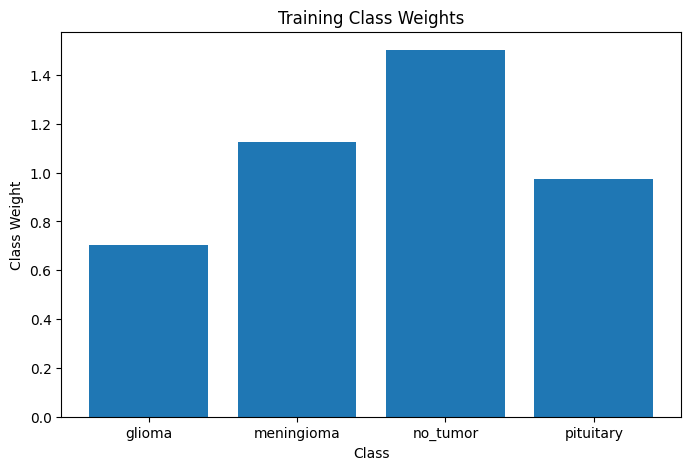

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    CLASS_TO_INDEX.keys(),
    class_weights.values()
)

plt.xlabel("Class")
plt.ylabel("Class Weight")
plt.title("Training Class Weights")

plt.show()

## **CNN Architecture**

In [37]:
model = models.Sequential([

    # Input
    layers.Input(shape=(224, 224, 1)),

    # Block 1
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(
        32, (3, 3),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.20),

    # Block 2
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(
        64, (3, 3),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(
        128, (3, 3),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(
        128, (3, 3),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.30),

    # Block 4
    layers.Conv2D(
        256, (3, 3),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.30),

    # Classification head
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.40),

    layers.Dense(
        4,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             

 Total params: 617,124 (2.35 MB)

 Trainable params: 615,716 (2.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

## **Model Compilation**

In [38]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=2.5e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

## **Training Callbacks**

In [39]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

## **Model Training**

In [40]:
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 113s 345ms/step - accuracy: 0.6138 - loss: 0.9086 - val_accuracy: 0.3554 - val_loss: 3.2435 - learning_rate: 2.5000e-04
Epoch 2/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 84s 343ms/step - accuracy: 0.6880 - loss: 0.7285 - val_accuracy: 0.3554 - val_loss: 3.8657 - learning_rate: 2.5000e-04
Epoch 3/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 82s 331ms/step - accuracy: 0.7370 - loss: 0.6329 - val_accuracy: 0.6307 - val_loss: 1.1596 - learning_rate: 2.5000e-04
Epoch 4/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 83s 337ms/step - accuracy: 0.7647 - loss: 0.5674 - val_accuracy: 0.4912 - val_loss: 1.5895 - learning_rate: 2.5000e-04
Epoch 5/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 83s 338ms/step - accuracy: 0.7933 - loss: 0.5165 - val_accuracy: 0.6705 - val_loss: 1.0729 - learning_rate: 2.5000e-04
Epoch 6/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 82s 331ms/step - accuracy: 0.7934 - loss: 0.5009 - val_accuracy: 0.5505 - val_loss: 1.4914 - learning_rate: 2.5000e-04
Epoch 7/30
231/231 ━━━━━━━━━━━━━━━━━━━━ 81s 3

### **Training and Validation Performance**

In [46]:
# Extract training history
history_dict = history.history

train_accuracy = history_dict["accuracy"]
val_accuracy = history_dict["val_accuracy"]

train_loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

epochs = range(1, len(train_accuracy) + 1)

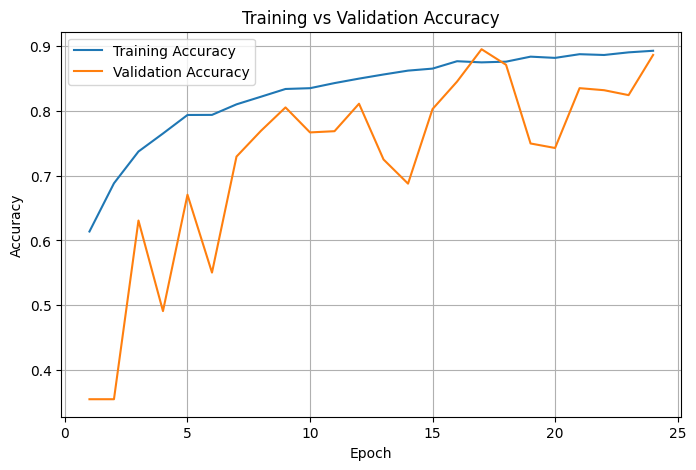

In [47]:
# Accuracy Curve

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracy, label="Training Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

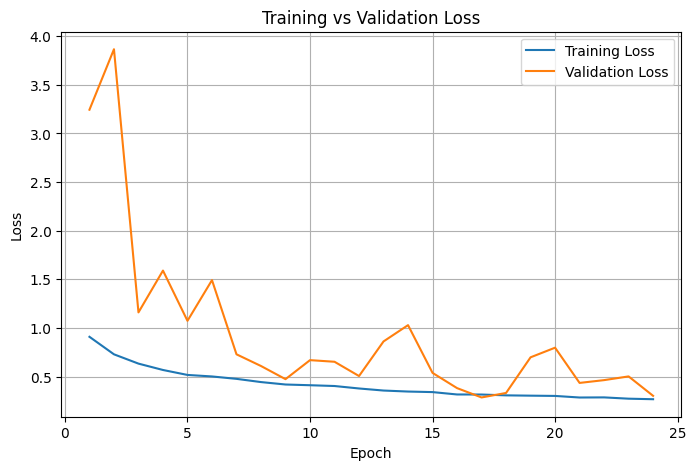

In [48]:
# Loss Curve
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

## **Model Testing**

In [41]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8838 - loss: 0.3022

Test Loss: 0.3022
Test Accuracy: 0.8838
Test Accuracy: 88.38%


## **Generate Test Predictions**

In [42]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of test samples:", len(y_true))
print("Predictions generated:", len(y_pred))

Number of test samples: 1584
Predictions generated: 1584


## **Classification Report**

In [43]:
class_names = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

      glioma     0.9463    0.8757    0.9096       563
  meningioma     0.7597    0.7812    0.7703       352
    no_tumor     0.9163    0.9163    0.9163       263
   pituitary     0.8927    0.9631    0.9265       406

    accuracy                         0.8838      1584
   macro avg     0.8787    0.8841    0.8807      1584
weighted avg     0.8861    0.8838    0.8841      1584



## **Confusion Matrix**

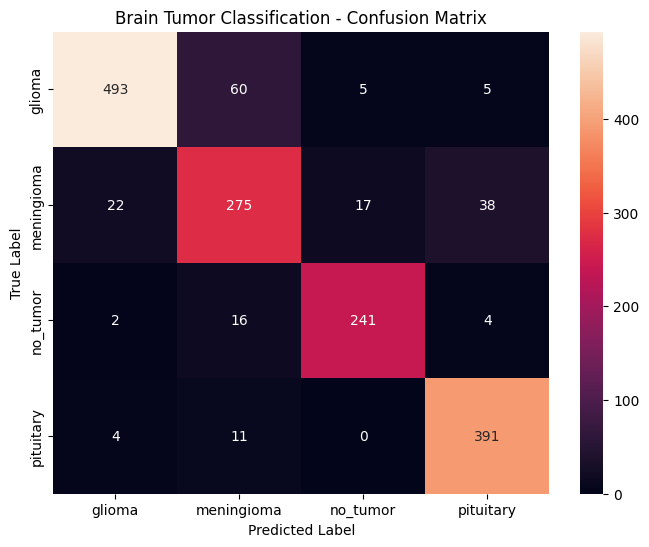

In [44]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Brain Tumor Classification - Confusion Matrix")

plt.show()

## **Tumor-to-No-Tumor Error Analysis**

In [45]:
tumor_classes = [
    CLASS_TO_INDEX["glioma"],
    CLASS_TO_INDEX["meningioma"],
    CLASS_TO_INDEX["pituitary"]
]

no_tumor_index = CLASS_TO_INDEX["no_tumor"]

tumor_actual = np.isin(
    y_true,
    tumor_classes
)

tumor_predicted_as_no_tumor = (
    tumor_actual &
    (y_pred == no_tumor_index)
)

false_negative_count = np.sum(
    tumor_predicted_as_no_tumor
)

total_tumor_images = np.sum(
    tumor_actual
)

tumor_missed_rate = (
    false_negative_count /
    total_tumor_images
)

print("Actual tumor images:", total_tumor_images)
print("Tumor images predicted as no_tumor:", false_negative_count)
print(f"Tumor missed rate: {tumor_missed_rate * 100:.2f}%")

Actual tumor images: 1321
Tumor images predicted as no_tumor: 22
Tumor missed rate: 1.67%


## **Final Model Saving**

In [49]:
# Save the finalized classification model
model_path = "/content/brain_tumor_classifier.keras"

model.save(model_path)

print(f"Model saved successfully at: {model_path}")

Model saved successfully at: /content/brain_tumor_classifier.keras
